# 심화 과제 4-1
## 금융 수익률 예측: 이분산 회귀 vs 분위수 회귀 예측 구간 비교

#### 과제 목적
합성 금융 수익률 데이터(변동성이 시장 상황에 따라 변함)에서 **이분산 회귀(Heteroscedastic Regression)** 와 **분위수 회귀(Quantile Regression)** 의 예측 구간을 4가지 지표로 정량 비교합니다.

| 평가 지표 | 설명 |
|---|---|
| **Coverage** | 실제 값이 예측 구간 내에 포함되는 비율 |
| **Standardized Residuals** | 예측 분포 기준으로 표준화한 잔차 분포 |
| **PIT Histogram** | Probability Integral Transform — 균등분포에 가까울수록 보정 잘 됨 |
| **Sharpness** | 예측 구간의 너비 (좁을수록 Sharp한 예측) |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글+마이너스 기호 둘 다 지원하는 폰트
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# AppleGothic에 없는 기호는 Arial로 fallback
fm.fontManager.addfont('/System/Library/Fonts/Supplemental/Arial.ttf')
plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Arial', 'DejaVu Sans']

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore') 
np.random.seed(42)  
tf.random.set_seed(42)  


---
## Step 1. 데이터 EDA
### 비가우시안 헤테로스케다스틱 금융 데이터 생성 및 시각화

In [3]:
# ── 데이터 생성 ─────────────────────────────────────────────────
# X: 시장 변동성 상태 변수 (0~1)
# Y: 일별 수익률 (비정규 이분산 노이즈)

n_samples = 2000
np.random.seed(42)

X = np.random.uniform(0, 1, n_samples)
sigma_x = 0.05 + 0.45 * X**2  # 이분산: 저변동성 → 고변동성으로 증가

# 비정규 노이즈: t분포(df=5) — 정규분포보다 꼬리가 두껍고 대칭
noise = np.random.standard_t(df=5, size=n_samples)
noise = noise / np.std(noise)  # 표준화
y = 0.1 * np.sin(2 * np.pi * X) + sigma_x * noise

X = X.reshape(-1, 1)

print(f"✓ 금융 이분산 데이터 생성 완료")
print(f"  X shape  : {X.shape}")
print(f"  y shape  : {y.shape}")
print(f"  σ(x) 범위: [{sigma_x.min():.3f}, {sigma_x.max():.3f}]")
print(f"  노이즈 왜도: {stats.skew(noise):.3f}")
print(f"  노이즈 첨도: {stats.kurtosis(noise):.3f}")

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

✓ 금융 이분산 데이터 생성 완료
  X shape  : (2000, 1)
  y shape  : (2000,)
  σ(x) 범위: [0.050, 0.500]
  노이즈 왜도: 0.329
  노이즈 첨도: 3.995


- 저변동성 구간은 수익률이 0 근처에 집중 → 예측하기 쉬움
- 고변동성 구간은 수익률이 넓게 퍼지고, 오른쪽 꼬리가 왼쪽보다 훨씬 길다 (비대칭)
- 이분산 회귀를 쓰면 오른쪽 꼬리를 놓칠 수 있다

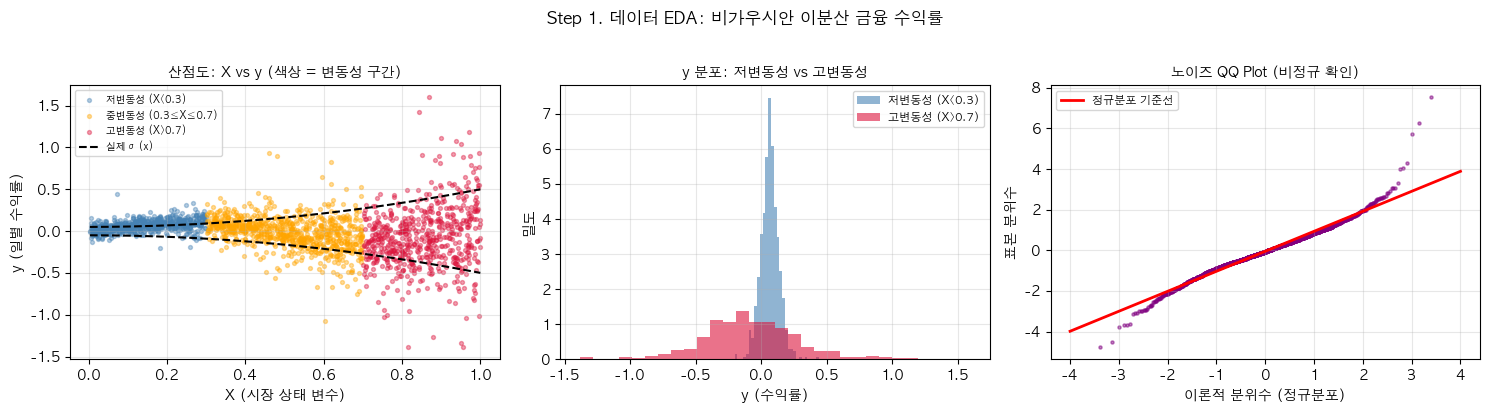

[EDA 요약]
  저변동성 구간 y 표준편차: 0.0696
  중변동성 구간 y 표준편차: 0.1938
  고변동성 구간 y 표준편차: 0.3729
  노이즈 왜도: 0.329 → 오른쪽 꼬리 (양의 왜도)
  노이즈 첨도: 3.995 → 정규분포 대비 두꺼운 꼬리


In [4]:
# ── EDA 시각화 ─────────────────────────────────────────────────────
# 변동성 구간 정의
LOW_MASK  = X.flatten() < 0.3
MID_MASK  = (X.flatten() >= 0.3) & (X.flatten() <= 0.7)
HIGH_MASK = X.flatten() > 0.7

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) 산점도: X vs y
ax = axes[0]
sort_idx = np.argsort(X.flatten())
X_sorted = X.flatten()[sort_idx]
ax.scatter(X.flatten()[LOW_MASK],  y[LOW_MASK],  alpha=0.4, s=8, color='steelblue',  label='저변동성 (X<0.3)')
ax.scatter(X.flatten()[MID_MASK],  y[MID_MASK],  alpha=0.4, s=8, color='orange',     label='중변동성 (0.3≤X≤0.7)')
ax.scatter(X.flatten()[HIGH_MASK], y[HIGH_MASK], alpha=0.4, s=8, color='crimson',    label='고변동성 (X>0.7)')
true_sigma = 0.05 + 0.45 * X_sorted**2
ax.plot(X_sorted,  true_sigma, 'k--', lw=1.5, label='실제 σ(x)')  # 실제 표준편차 상한
ax.plot(X_sorted, -true_sigma, 'k--', lw=1.5)                      # 실제 표준편차 하한
ax.set_title('산점도: X vs y (색상 = 변동성 구간)', fontsize=10, fontweight='bold')
ax.set_xlabel('X (시장 상태 변수)')
ax.set_ylabel('y (일별 수익률)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (2) y 분포 비교 (저변동성 vs 고변동성)
ax = axes[1]
ax.hist(y[LOW_MASK],  bins=30, density=True, alpha=0.6, color='steelblue', label='저변동성 (X<0.3)')
ax.hist(y[HIGH_MASK], bins=30, density=True, alpha=0.6, color='crimson',   label='고변동성 (X>0.7)')
ax.set_title('y 분포: 저변동성 vs 고변동성', fontsize=10, fontweight='bold')
ax.set_xlabel('y (수익률)')
ax.set_ylabel('밀도')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (3) 비정규 노이즈 확인 (QQ Plot)
ax = axes[2]
(osm, osr), (slope, intercept, _) = stats.probplot(noise, dist='norm')
ax.scatter(osm, osr, s=5, alpha=0.5, color='purple')
ax.plot([-4, 4], [slope*-4+intercept, slope*4+intercept], 'r-', lw=2, label='정규분포 기준선')
ax.set_title('노이즈 QQ Plot (비정규 확인)', fontsize=10, fontweight='bold')
ax.set_xlabel('이론적 분위수 (정규분포)')
ax.set_ylabel('표본 분위수')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Step 1. 데이터 EDA: 비가우시안 이분산 금융 수익률', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("[EDA 요약]")
print(f"  저변동성 구간 y 표준편차: {y[LOW_MASK].std():.4f}")
print(f"  중변동성 구간 y 표준편차: {y[MID_MASK].std():.4f}")
print(f"  고변동성 구간 y 표준편차: {y[HIGH_MASK].std():.4f}")
print(f"  노이즈 왜도: {stats.skew(noise):.3f} → 오른쪽 꼬리 (양의 왜도)")
print(f"  노이즈 첨도: {stats.kurtosis(noise):.3f} → 정규분포 대비 {'두꺼운' if stats.kurtosis(noise)>0 else '얇은'} 꼬리")


---
## Step 2. 이분산 회귀(Heteroscedastic Regression) 학습
- `build_hetero_regressor`: μ(x), log σ²(x) 동시 출력
- 손실함수: Gaussian NLL (Negative Log-Likelihood)

In [5]:
# ── 이분산 회귀 모델 정의 ──────────────────────────────────────────────────────────
def build_hetero_regressor(input_dim=1, hidden_units=64):
    # μ(x)와 log σ²(x)를 동시에 예측하는 이분산 회귀 모델
    inputs = keras.Input(shape=(input_dim,))
    h = layers.Dense(hidden_units, activation='relu')(inputs)
    h = layers.Dense(hidden_units, activation='relu')(h)
    h = layers.Dense(32, activation='relu')(h)
    
    # 평균 출력
    mu    = layers.Dense(1, name='mu')(h)
    # 로그 분산 출력 (수치 안정성을 위해 log σ²를 예측)
    log_var = layers.Dense(1, name='log_var')(h)
    
    model = keras.Model(inputs=inputs, outputs=[mu, log_var])
    return model


def gaussian_nll_loss(y_true, mu, log_var):
    #가우시안 음의 로그우도(NLL) 손실함수
    #NLL = 0.5 * [log(σ²) + (y - μ)² / σ²]
    y_true = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
    precision = tf.exp(-log_var)  # 1/σ² (정밀도)
    nll = 0.5 * (log_var + (y_true - mu) ** 2 * precision)
    return tf.reduce_mean(nll)


# 모델 생성
hetero_model = build_hetero_regressor(input_dim=1)
hetero_model.summary()
print("\n✓ 이분산 회귀 모델 생성 완료")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,434 (25.13 KB)

 Trainable params: 6,434 (25.13 KB)

 Non-trainable params: 0 (0.00 B)


✓ 이분산 회귀 모델 생성 완료


  Epoch  50/300 | NLL 손실: -1.3374
  Epoch 100/300 | NLL 손실: -1.3497
  Epoch 150/300 | NLL 손실: -1.3583
  Epoch 200/300 | NLL 손실: -1.3680
  Epoch 250/300 | NLL 손실: -1.3654
  Epoch 300/300 | NLL 손실: -1.3684

✓ 이분산 회귀 학습 완료


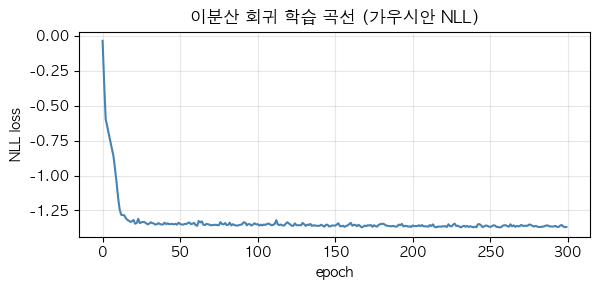

In [6]:
# ── 이분산 회귀 학습 ────────────────────────────────────────────────────────────
optimizer_hetero = keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_hetero_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu, log_var = hetero_model(X_batch, training=True)
        loss = gaussian_nll_loss(y_batch, mu, log_var)  # NLL 손실 계산
    grads = tape.gradient(loss, hetero_model.trainable_variables)  # 그래디언트 계산
    optimizer_hetero.apply_gradients(zip(grads, hetero_model.trainable_variables))  # 가중치 업데이트
    return loss


EPOCHS_HETERO = 300  # 학습 에폭 수
BATCH_SIZE    = 64   # 미니배치 크기
dataset = tf.data.Dataset.from_tensor_slices(
    (X_train.astype('float32'), y_train.astype('float32'))
).shuffle(len(X_train)).batch(BATCH_SIZE)  # 데이터셋 셔플 후 배치 분할

hetero_losses = []
for epoch in range(EPOCHS_HETERO):
    epoch_loss = []
    for X_b, y_b in dataset:
        loss = train_hetero_step(X_b, y_b)
        epoch_loss.append(loss.numpy())
    hetero_losses.append(np.mean(epoch_loss))  # 에폭별 평균 손실 저장
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS_HETERO} | NLL 손실: {hetero_losses[-1]:.4f}")

print("\n✓ 이분산 회귀 학습 완료")

# 학습 곡선 시각화
plt.figure(figsize=(6, 3))
plt.plot(hetero_losses, color='steelblue')
plt.title('이분산 회귀 학습 곡선 (가우시안 NLL)', fontweight='bold')
plt.xlabel('epoch')
plt.ylabel('NLL loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
print(f"  초기 NLL 손실: {hetero_losses[0]:.4f}")
print(f"  최종 NLL 손실: {hetero_losses[-1]:.4f}")
print(f"  손실 변화량: {hetero_losses[-1] - hetero_losses[0]:.4f}")

  초기 NLL 손실: -0.0361
  최종 NLL 손실: -1.3684
  손실 변화량: -1.3322


In [ ]:
# ── 이분산 회귀: 테스트 예측 ─────────────────────────────────────────────────────
mu_pred, log_var_pred = hetero_model.predict(X_test.astype('float32'), verbose=0)
mu_pred    = mu_pred.flatten()
sigma_pred = np.exp(0.5 * log_var_pred.flatten())  # σ = exp(0.5 * log σ²) 로 분산→표준편차 변환

# 80% 예측 구간: μ ± 1.28σ (정규분포 80% 구간)
hetero_lower = mu_pred - 1.28 * sigma_pred  # 하한
hetero_upper = mu_pred + 1.28 * sigma_pred  # 상한

print(f"✓ 이분산 회귀 예측 완료")
print(f"  μ 범위    : [{mu_pred.min():.4f}, {mu_pred.max():.4f}]")
print(f"  σ 범위    : [{sigma_pred.min():.4f}, {sigma_pred.max():.4f}]")


✓ 이분산 회귀 예측 완료
  μ 범위    : [-0.1520, 0.0989]
  σ 범위    : [0.0506, 0.4284]


---
## Step 3. 분위수 회귀(Quantile Regression) 학습
- `build_quantile_regressor`: 10%, 50%, 90% 분위수 동시 예측
- 손실함수: Pinball Loss (분위수 손실)

In [8]:
# ── 분위수 회귀 모델 정의 ──────────────────────────────────────
def build_quantile_regressor(input_dim=1, quantiles=[0.1, 0.5, 0.9], hidden_units=64):
    # 여러 분위수를 동시에 예측하는 모델
    inputs = keras.Input(shape=(input_dim,))
    h = layers.Dense(hidden_units, activation='relu')(inputs)
    h = layers.Dense(hidden_units, activation='relu')(h)
    h = layers.Dense(32, activation='relu')(h)
    outputs = [
        layers.Dense(1, name=f'q_{int(q*100)}')(h)
        for q in quantiles
    ]
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, quantiles


def pinball_loss(quantile):
    # Pinball Loss: L_τ(y, q) = max(τ·(y-q), (τ-1)·(y-q))
    def loss(y_true, y_pred):
        residuals = y_true - y_pred
        return tf.reduce_mean(
            tf.maximum(quantile * residuals, (quantile - 1) * residuals)
        )
    return loss


def asymmetric_pinball(quantile, skew_factor=1.5):
    # 꼬리가 두꺼운 데이터에서 상위 분위수 학습 강화
    def loss(y_true, y_pred):
        residuals = y_true - y_pred
        if quantile > 0.5:
            return tf.reduce_mean(
                tf.maximum(quantile * skew_factor * residuals,
                           (quantile - 1) * residuals)
            )
        else:
            return tf.reduce_mean(
                tf.maximum(quantile * residuals,
                           (quantile - 1) * residuals)
            )
    return loss


# ★ hidden_units=128 (튜닝)
QUANTILES = [0.1, 0.5, 0.9]
quant_model, quants = build_quantile_regressor(
    input_dim=1, quantiles=QUANTILES, hidden_units=128
)
quant_model.summary()
print("\n✓ 분위수 회귀 모델 생성 완료")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      4,128 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_10 (Dense)        │ (None, 1)         │         33 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_50 (Dense)        │ (None, 1)         │         33 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_90 (Dense)        │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,995 (82.01 KB)

 Trainable params: 20,995 (82.01 KB)

 Non-trainable params: 0 (0.00 B)


✓ 분위수 회귀 모델 생성 완료


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

✓ 분위수 회귀 학습 완료


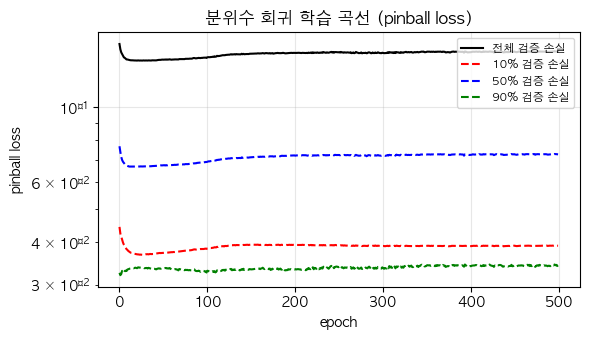

In [9]:
# ── 분위수 회귀 컴파일 & 학습 ─────────────────────────────────
# Q10: asymmetric pinball (하위 꼬리 강화)
# Q50: 일반 pinball
# Q90: asymmetric pinball, skew_factor=1.5 (상위 꼬리 강화)
loss_dict = {
    'q_10': asymmetric_pinball(0.1),
    'q_50': pinball_loss(0.5),
    'q_90': asymmetric_pinball(0.9, skew_factor=1.5),
}

quant_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),  # ★ 3e-4
    loss=loss_dict
)

history_quant = quant_model.fit(
    X_train.astype('float32'),
    [y_train.astype('float32')] * len(QUANTILES),  # ★ 원본 y (로그 변환 제거)
    epochs=500,       # ★ 500
    batch_size=32,    # ★ 32
    validation_split=0.1,
    shuffle=True,
    verbose=0
)
print("✓ 분위수 회귀 학습 완료")

# 학습 곡선
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history_quant.history['val_loss'],      label='전체 검증 손실',  color='black')
ax.plot(history_quant.history['val_q_10_loss'], label='10% 검증 손실', linestyle='--', color='red')
ax.plot(history_quant.history['val_q_50_loss'], label='50% 검증 손실', linestyle='--', color='blue')
ax.plot(history_quant.history['val_q_90_loss'], label='90% 검증 손실', linestyle='--', color='green')
ax.set_title('분위수 회귀 학습 곡선 (pinball loss)', fontweight='bold')
ax.set_xlabel('epoch')
ax.set_ylabel('pinball loss')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ── 분위수 회귀: 테스트 예측 ─────────────────────────────────
quant_raw = quant_model.predict(X_test.astype('float32'), verbose=0)
q10_pred = quant_raw[0].flatten()
q50_pred = quant_raw[1].flatten()
q90_pred = quant_raw[2].flatten()

print(f"✓ 분위수 회귀 예측 완료")
print(f"  Q10 범위 : [{q10_pred.min():.4f}, {q10_pred.max():.4f}]")
print(f"  Q50 범위 : [{q50_pred.min():.4f}, {q50_pred.max():.4f}]")
print(f"  Q90 범위 : [{q90_pred.min():.4f}, {q90_pred.max():.4f}]")

cross_10_50 = q10_pred > q50_pred
cross_50_90 = q50_pred > q90_pred
crossing_rate = np.mean(cross_10_50 | cross_50_90)
print(f"\n  분위수 역전 비율: {crossing_rate:.4%} ({np.sum(cross_10_50 | cross_50_90)} / {len(y_test)} 샘플)")

✓ 분위수 회귀 예측 완료
  Q10 범위 : [-0.5139, 0.0317]
  Q50 범위 : [-0.1515, 0.1183]
  Q90 범위 : [0.1121, 0.8005]

  분위수 역전 비율: 0.0000% (0 / 400 샘플)


---
## Step 4. 변동성 구간별 성능 비교

저변동성(X<0.3) / 중변동성(0.3≤X≤0.7) / 고변동성(X>0.7) 세 구간에 대해  
Coverage / Standardized Residuals / PIT Histogram / Sharpness 비교

In [11]:
# ── 공통 유틸리티 함수 ──────────────────────────────────────────────────
def get_zone_mask(X_arr, zone):
    """변동성 구간별 마스크 반환"""
    x = X_arr.flatten()
    if zone == 'low':
        return x < 0.3          # 저변동성 구간
    elif zone == 'mid':
        return (x >= 0.3) & (x <= 0.7)  # 중변동성 구간
    else:  # high
        return x > 0.7          # 고변동성 구간

def compute_metrics(y_true, lower, upper, mean_pred, std_pred):
    """Coverage / Sharpness / 표준화 잔차 / PIT 계산"""
    # 커버리지: 실제 값이 예측 구간 안에 포함되는 비율
    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    # 선명도(Sharpness): 예측 구간의 평균 너비 (좁을수록 좋음)
    sharpness = np.mean(upper - lower)
    # 표준화 잔차: (실제값 - 예측 평균) / 예측 표준편차
    std_res = (y_true - mean_pred) / (std_pred + 1e-8)
    # PIT 값 (가우시안 근사를 통한 확률 적분 변환)
    pit_vals = stats.norm.cdf(y_true, loc=mean_pred, scale=std_pred + 1e-8)
    return {'coverage': coverage, 'sharpness': sharpness,
            'std_res': std_res, 'pit': pit_vals}

# ── 이분산 회귀: 예측 표준편차 (모델에서 직접 추출)
hetero_std = sigma_pred

# ── 분위수 회귀: 가우시안 근사 (80% 구간 역산 → σ)
quant_std  = (q90_pred - q10_pred) / (2 * 1.28)

ZONES = {
    'low':  ('저변동성 (X<0.3)',    'steelblue'),
    'mid':  ('중변동성 (0.3≤X≤0.7)', 'orange'),
    'high': ('고변동성 (X>0.7)',    'crimson'),
}

print(f"{'구간':<22} {'모델':<8} {'커버리지':>10} {'선명도':>10} {'|표준화잔차| 평균':>16} {'PIT 균일성':>13}")
print("-" * 82)

results = {}
for zone, (label, _) in ZONES.items():
    mask = get_zone_mask(X_test, zone)
    if mask.sum() == 0:
        continue
    yt = y_test[mask]

    # 이분산 회귀 지표 계산
    m_h = compute_metrics(yt, hetero_lower[mask], hetero_upper[mask],
                          mu_pred[mask], hetero_std[mask])
    # 분위수 회귀 지표 계산 (80% 구간: Q10~Q90)
    m_q = compute_metrics(yt, q10_pred[mask], q90_pred[mask],
                          q50_pred[mask], quant_std[mask])
    
    results[zone] = {'hetero': m_h, 'quant': m_q, 'label': label, 'mask': mask}
    
    # PIT 균일성: 카이제곱 검정 p-value (높을수록 균일분포에 가까움)
    pit_h_bins, _ = np.histogram(m_h['pit'], bins=10, range=(0, 1))
    pit_q_bins, _ = np.histogram(m_q['pit'], bins=10, range=(0, 1))
    _, p_h = stats.chisquare(pit_h_bins)
    _, p_q = stats.chisquare(pit_q_bins)

    print(f"{label:<22} {'이분산':>8} {m_h['coverage']:>10.3f} {m_h['sharpness']:>10.4f} {np.abs(m_h['std_res']).mean():>16.4f} {p_h:>13.4f}")
    print(f"{' ':<22} {'분위수':>8} {m_q['coverage']:>10.3f} {m_q['sharpness']:>10.4f} {np.abs(m_q['std_res']).mean():>16.4f} {p_q:>13.4f}")
    print("-" * 82)


구간                     모델             커버리지        선명도       |표준화잔차| 평균       PIT 균일성
----------------------------------------------------------------------------------
저변동성 (X<0.3)                이분산      0.842     0.1574           0.7346        0.0030
                            분위수      0.825     0.1704           0.6764        0.0010
----------------------------------------------------------------------------------
중변동성 (0.3≤X≤0.7)            이분산      0.807     0.4067           0.8587        0.0268
                            분위수      0.851     0.4720           0.7174        0.0001
----------------------------------------------------------------------------------
고변동성 (X>0.7)                이분산      0.815     0.8541           0.8191        0.8529
                            분위수      0.840     0.9567           0.7462        0.1776
----------------------------------------------------------------------------------


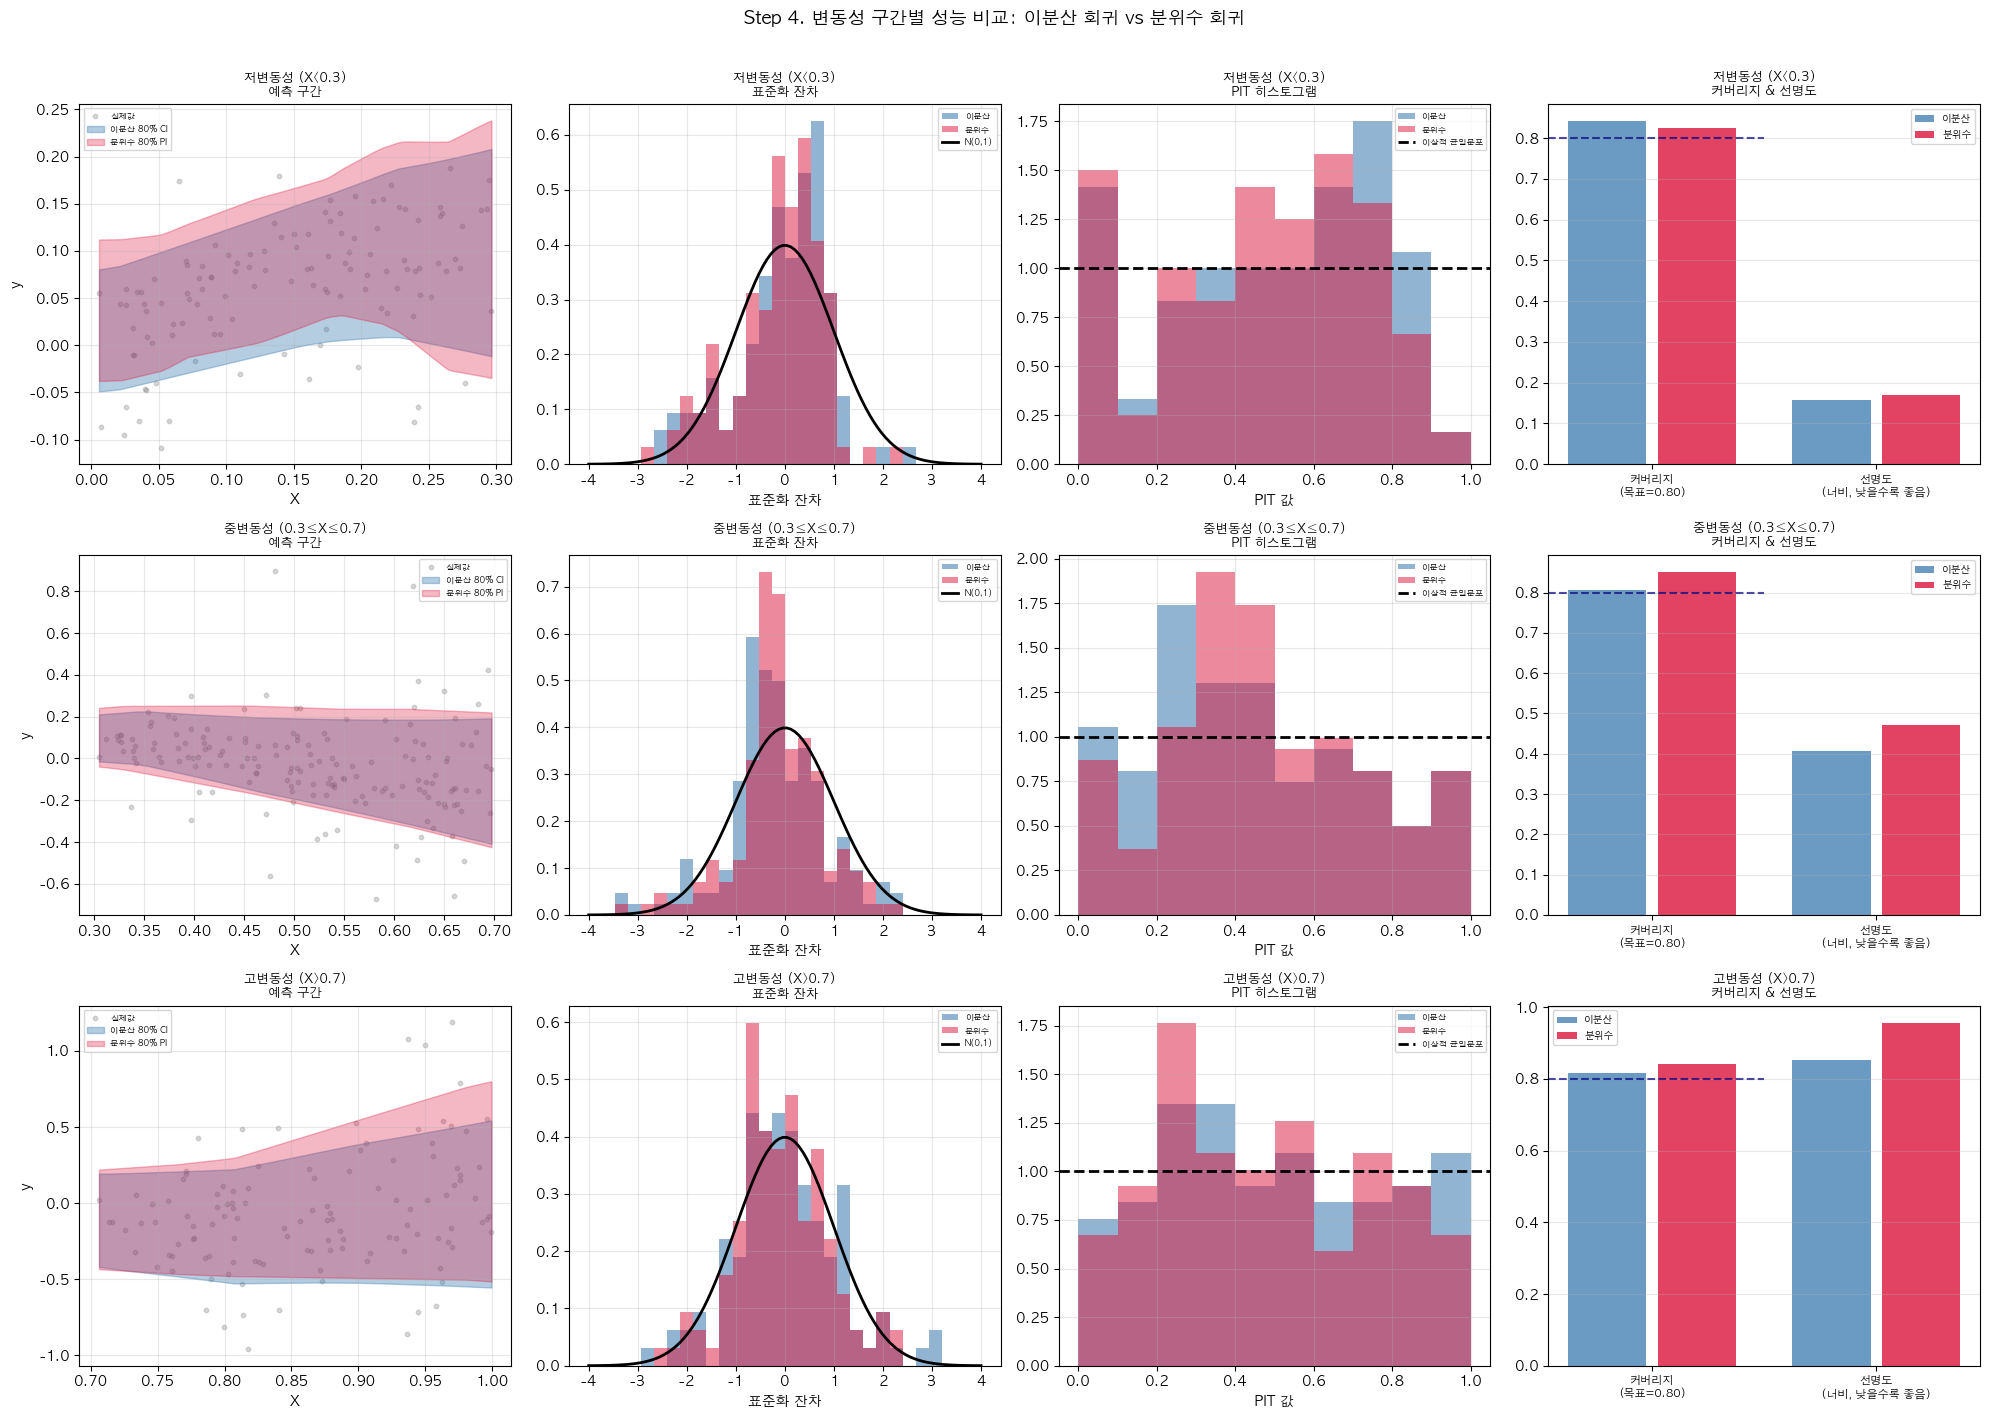

In [12]:
# ── 변동성 구간별 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Step 4. 변동성 구간별 성능 비교: 이분산 회귀 vs 분위수 회귀',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (zone, (label, color)) in enumerate(ZONES.items()):
    res = results[zone]
    m_h, m_q = res['hetero'], res['quant']
    mask = res['mask']
    yt = y_test[mask]
    x_zone = X_test.flatten()[mask]
    sort_z = np.argsort(x_zone)  # 시각화를 위한 정렬 인덱스

    # (열 0) 예측 구간 시각화
    ax = axes[row_idx, 0]
    ax.scatter(x_zone, yt, alpha=0.3, s=10, color='gray', label='실제값')
    ax.fill_between(x_zone[sort_z],
                    hetero_lower[mask][sort_z], hetero_upper[mask][sort_z],
                    alpha=0.4, color='steelblue', label='이분산 80% CI')
    ax.fill_between(x_zone[sort_z],
                    q10_pred[mask][sort_z], q90_pred[mask][sort_z],
                    alpha=0.3, color='crimson', label='분위수 80% PI')
    ax.set_title(f'{label}\n예측 구간', fontsize=9, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

    # (열 1) 표준화 잔차 히스토그램
    ax = axes[row_idx, 1]
    bins_r = np.linspace(-4, 4, 31)
    ax.hist(m_h['std_res'], bins=bins_r, density=True, alpha=0.6, color='steelblue', label='이분산')
    ax.hist(m_q['std_res'], bins=bins_r, density=True, alpha=0.5, color='crimson',   label='분위수')
    xg = np.linspace(-4, 4, 100)
    ax.plot(xg, stats.norm.pdf(xg), 'k-', lw=2, label='N(0,1)')  # 표준정규분포 기준선
    ax.set_title(f'{label}\n표준화 잔차', fontsize=9, fontweight='bold')
    ax.set_xlabel('표준화 잔차')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

    # (열 2) PIT 히스토그램
    ax = axes[row_idx, 2]
    bins_p = np.linspace(0, 1, 11)
    ax.hist(m_h['pit'], bins=bins_p, density=True, alpha=0.6, color='steelblue', label='이분산')
    ax.hist(m_q['pit'], bins=bins_p, density=True, alpha=0.5, color='crimson',   label='분위수')
    ax.axhline(y=1.0, color='k', lw=2, linestyle='--', label='이상적 균일분포')  # 이상적 PIT 기준선
    ax.set_title(f'{label}\nPIT 히스토그램', fontsize=9, fontweight='bold')
    ax.set_xlabel('PIT 값')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

    # (열 3) Coverage & Sharpness 막대 비교
    ax = axes[row_idx, 3]
    metrics_labels = ['커버리지\n(목표=0.80)', '선명도\n(너비, 낮을수록 좋음)']
    h_vals = [m_h['coverage'], m_h['sharpness']]
    q_vals = [m_q['coverage'], m_q['sharpness']]
    x_pos = np.arange(len(metrics_labels))
    ax.bar(x_pos - 0.2, h_vals, 0.35, label='이분산', color='steelblue', alpha=0.8)
    ax.bar(x_pos + 0.2, q_vals, 0.35, label='분위수', color='crimson',   alpha=0.8)
    ax.axhline(y=0.80, xmin=0, xmax=0.5, color='navy', linestyle='--', lw=1.5, alpha=0.7)  # 목표 커버리지 기준선
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics_labels, fontsize=8)
    ax.set_title(f'{label}\n커버리지 & 선명도', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


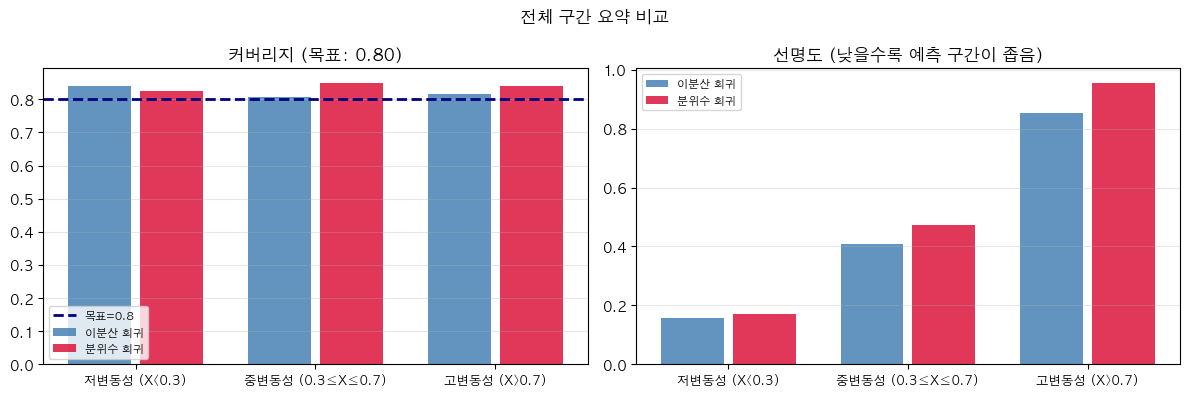

In [13]:
# ── 전체 구간 요약 비교 플롯 ─────────────────────────────────────────────
zone_labels  = [v[0] for v in ZONES.values()]
coverage_h   = [results[z]['hetero']['coverage']  for z in ZONES]  # 이분산 회귀 커버리지
coverage_q   = [results[z]['quant']['coverage']   for z in ZONES]  # 분위수 회귀 커버리지
sharpness_h  = [results[z]['hetero']['sharpness'] for z in ZONES]  # 이분산 회귀 선명도
sharpness_q  = [results[z]['quant']['sharpness']  for z in ZONES]  # 분위수 회귀 선명도

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('전체 구간 요약 비교', fontsize=12, fontweight='bold')

x = np.arange(len(zone_labels))
for ax, h_vals, q_vals, title, target_line in zip(
    axes,
    [coverage_h,  sharpness_h],
    [coverage_q,  sharpness_q],
    ['커버리지 (목표: 0.80)',  '선명도 (낮을수록 예측 구간이 좁음)'],
    [0.80,        None]  # 커버리지는 0.80 기준선 표시, 선명도는 없음
):
    ax.bar(x - 0.2, h_vals, 0.35, label='이분산 회귀', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, q_vals, 0.35, label='분위수 회귀', color='crimson',   alpha=0.85)
    if target_line is not None:
        ax.axhline(y=target_line, color='navy', linestyle='--', lw=2, label=f'목표={target_line}')  # 목표 기준선
    ax.set_xticks(x)
    ax.set_xticklabels(zone_labels, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
